In [5]:
import scipy.io
import numpy as np
from scipy.signal import welch
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# --------- STEP 1: Spectral Entropy Function ---------
def spectral_entropy(signal, sf=256, nperseg=None):
    """Compute spectral entropy of a 1D signal."""
    freqs, psd = welch(signal, sf, nperseg=nperseg)
    psd_norm = psd / np.sum(psd)  # Normalize
    return entropy(psd_norm)

# --------- STEP 2: Load EEG Data ---------
input_mat = '/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET/DATASET (NEW)/cooperate.mat'  # Replace with your path
output_mat = 'entropy_cooperate.mat'

mat = scipy.io.loadmat(input_mat)
eeg_key = [k for k in mat.keys() if not k.startswith('__')][0]
eeg_data = mat[eeg_key]  # shape (rows, cols), each cell: (channels, timepoints)
rows, cols = eeg_data.shape
print(f"Loaded EEG data of shape: {eeg_data.shape}")

# --------- STEP 3: Apply Spectral Entropy-Based Selection ---------
selected_data = np.empty((rows, cols), dtype=object)

for i in range(rows):
    for j in range(cols):
        sample = eeg_data[i, j]  # shape: (channels, timepoints)
        if isinstance(sample, np.ndarray) and sample.ndim == 2 and sample.shape[0] >= 40:
            entropies = [spectral_entropy(sample[ch, :]) for ch in range(sample.shape[0])]
            top40_idx = np.argsort(entropies)[-40:]  # 🔁 Top 40 highest entropy
            top40_idx = np.sort(top40_idx)  # (optional) keep original order
            selected_data[i, j] = sample[top40_idx, :]
        else:
            selected_data[i, j] = sample  # leave as-is for invalid data

# --------- STEP 4: Save the Filtered Data ---------
scipy.io.savemat(output_mat, {'eeg_selected': selected_data})
print(f"✅ Saved top 40 spectral entropy channel EEG to: {output_mat}")

Loaded EEG data of shape: (6, 100)
✅ Saved top 40 spectral entropy channel EEG to: entropy_cooperate.mat


In [ ]:



# segment Window Size.  Step Size.    Overlap %.    Segments in 5 sec
#.            3 sec.      1 sec.          66%              3


import numpy as np
from scipy.io import loadmat, savemat

# Load original EEG data
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/mat data/cooperate_top40.mat')
mat_key = 'eeg_selected'
eeg_data = data[mat_key]
print("Original EEG shape:", eeg_data.shape)  # (8, 100)

# Settings
fs = 256  # Sampling frequency
window_size = 3 * fs  # 3 seconds = 768 samples
step_size = 1 * fs    # 1 second = 256 samples
segments_per_trial = 3  # 5 sec trial → 3 segments (66% overlap)

# Shape placeholders
rows, cols = eeg_data.shape
combined_data = np.empty((rows, cols * segments_per_trial), dtype=object)

# Segment with overlap
for i in range(rows):
    for j in range(cols):
        signal = eeg_data[i, j]
        if isinstance(signal, np.ndarray) and signal.shape[1] >= window_size:
            for k in range(segments_per_trial):
                start = k * step_size
                end = start + window_size
                if end <= signal.shape[1]:
                    combined_data[i, j * segments_per_trial + k] = signal[:, start:end]
                else:
                    print(f"⚠️ Segment out of bounds at ({i}, {j}, {k})")
        else:
            print(f"⚠️ Unexpected shape at ({i}, {j}):", signal.shape)

# Save final .mat file
savemat('cooperate_3sec.mat', {mat_key: combined_data})
print("Available keys:", data.keys())


print("✅ Final combined file with 3s window & 1s step saved. Shape:", combined_data.shape)

In [8]:
import scipy.io

# Path to your .mat file
mat_file = '/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/entropy_a.mat'

# Load the .mat file
mat_data = scipy.io.loadmat(mat_file)

# List all keys (excluding metadata like __header__)
keys = [key for key in mat_data.keys() if not key.startswith('__')]

print("✅ Keys in the .mat file:")
for key in keys:
    print(f"- {key}")

✅ Keys in the .mat file:
- eeg_selected


In [13]:



# segment Window Size.  Step Size.    Overlap %.    Segments in 5 sec
#.            3 sec.      1 sec.          66%              3


import numpy as np
from scipy.io import loadmat, savemat

# Load original EEG data
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/entropy_cooperate.mat')
mat_key = 'eeg_selected'
eeg_data = data[mat_key]
print("Original EEG shape:", eeg_data.shape)  # (8, 100)

# Settings
fs = 256  # Sampling frequency
window_size = 3 * fs  # 3 seconds = 768 samples
step_size = 1 * fs    # 1 second = 256 samples
segments_per_trial = 3  # 5 sec trial → 3 segments (66% overlap)

# Shape placeholders
rows, cols = eeg_data.shape
combined_data = np.empty((rows, cols * segments_per_trial), dtype=object)

# Segment with overlap
for i in range(rows):
    for j in range(cols):
        signal = eeg_data[i, j]
        if isinstance(signal, np.ndarray) and signal.shape[1] >= window_size:
            for k in range(segments_per_trial):
                start = k * step_size
                end = start + window_size
                if end <= signal.shape[1]:
                    combined_data[i, j * segments_per_trial + k] = signal[:, start:end]
                else:
                    print(f"⚠️ Segment out of bounds at ({i}, {j}, {k})")
        else:
            print(f"⚠️ Unexpected shape at ({i}, {j}):", signal.shape)

# Save final .mat file
savemat('cooperate1.mat', {mat_key: combined_data})
print("Available keys:", data.keys())


print("✅ Final combined file with 3s window & 1s step saved. Shape:", combined_data.shape)

Original EEG shape: (6, 100)
Available keys: dict_keys(['__header__', '__version__', '__globals__', 'eeg_selected'])
✅ Final combined file with 3s window & 1s step saved. Shape: (6, 300)


In [23]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.integrate import simps
from scipy.stats import kurtosis, skew
import pywt

# Set sampling frequency
fs = 256

# --- Feature Functions ---

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

def hjorth_params(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)
    activity = np.var(signal)
    mobility = np.std(d1) / (np.std(signal) + 1e-12)
    complexity = (np.std(d2) / (np.std(d1) + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def wavelet_entropy(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = np.array([np.sum(c**2) for c in coeffs])
    probs = energies / (np.sum(energies) + 1e-12)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    return entropy, np.sum(energies)

def frequency_statistics(freqs, psd):
    psd_norm = psd / np.sum(psd)
    mean_freq = np.sum(freqs * psd_norm)
    median_freq = freqs[np.searchsorted(np.cumsum(psd_norm), 0.5)]
    peak_freq = freqs[np.argmax(psd)]
    freq_var = np.sum((freqs - mean_freq) ** 2 * psd_norm)
    return mean_freq, median_freq, freq_var, peak_freq

# --- Feature Extractor for One Trial (averaged over 64 channels) ---

def extract_mean_features(trial):  # trial shape: (64, 640)
    feature_matrix = []
    for ch in trial:
        freqs, psd = welch(ch, fs=fs)

        # Time-domain features
        mean = np.mean(ch)
        std = np.std(ch)
        sk = skew(ch)
        kurt = kurtosis(ch)
        rms = np.sqrt(np.mean(ch**2))
        ptp = np.ptp(ch)

        # Hjorth features
        act, mob, comp = hjorth_params(ch)

        # Spectral features
        spec_ent = spectral_entropy(psd)
        total_power = simps(psd, freqs)
        mean_f, med_f, var_f, peak_f = frequency_statistics(freqs, psd)

        # Wavelet features
        wave_ent, coeff_energy = wavelet_entropy(ch)

        # Combine features
        features = [
            mean, std, sk, kurt, rms, ptp,
            act, mob, comp,
            spec_ent, total_power, wave_ent, coeff_energy,
            med_f, mean_f, var_f, peak_f
        ]
        feature_matrix.append(features)

    return np.mean(np.array(feature_matrix), axis=0)  # shape: (18,)

# --- Load EEG Data and Process All Trials ---

mat_path = "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/cooperate1.mat"
mat_key = "eeg_selected"

data = loadmat(mat_path)
eeg_data = data[mat_key]  # shape: (8, 200)

all_mean_features = []

for i in range(eeg_data.shape[0]):
    for j in range(eeg_data.shape[1]):
        trial = eeg_data[i, j]  # shape: (64, 640)
        trial_feats = extract_mean_features(trial)
        all_mean_features.append(trial_feats)

X = np.array(all_mean_features)  # shape: (1600, 18)
print("✅ Final mean feature matrix shape:", X.shape)

# --- Save to CSV with Feature Labels ---

feature_names = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak',
    'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
    'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy',
    'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency'
]

csv_path = "cooperate1_features.csv"
df = pd.DataFrame(X, columns=feature_names)
df.to_csv(csv_path, index=False)

print(f"✅ Mean features saved to: {csv_path}")

✅ Final mean feature matrix shape: (1800, 17)
✅ Mean features saved to: cooperate1_features.csv


In [24]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/cooperate1_features.csv", header=None)

# Add '0' as the last column
df['label'] = 4

# Save the updated CSV
df.to_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/cooperate1_features.csv", index=False, header=False)

In [25]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/a1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/i1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/u1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/cooperate1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/independent1_features.csv",
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("labels.csv", index=False)

In [26]:
import pandas as pd

# List your CSV files directly
csv_files = ["/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/a1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/i1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/u1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/cooperate1_features.csv",
    "/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/independent1_features.csv",
            ]

# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    if df.columns[-1] == "5":
        df.drop("5", axis=1, inplace=True)  # Remove the column explicitly by label
    else:
        df.drop(df.columns[-1], axis=1, inplace=True)  # Fallback: drop last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('combined.csv', index=False)

print("Combined CSV saved as 'combined.csv' without the last column '5'")

Combined CSV saved as 'combined.csv' without the last column '5'



===== Random Forest =====
Fold 1: Accuracy = 0.4102
Fold 2: Accuracy = 0.4435
Fold 3: Accuracy = 0.4241
Fold 4: Accuracy = 0.4389
Fold 5: Accuracy = 0.4481
Fold 6: Accuracy = 0.4204
Fold 7: Accuracy = 0.4426
Fold 8: Accuracy = 0.4380
Fold 9: Accuracy = 0.4528
Fold 10: Accuracy = 0.4463
Average Accuracy = 0.4365

===== Decision Tree =====
Fold 1: Accuracy = 0.3278
Fold 2: Accuracy = 0.3259
Fold 3: Accuracy = 0.3259
Fold 4: Accuracy = 0.3056
Fold 5: Accuracy = 0.3028
Fold 6: Accuracy = 0.3287
Fold 7: Accuracy = 0.3444
Fold 8: Accuracy = 0.3148
Fold 9: Accuracy = 0.3241
Fold 10: Accuracy = 0.3204
Average Accuracy = 0.3220

===== Gradient Boosting =====
Fold 1: Accuracy = 0.3444
Fold 2: Accuracy = 0.3991
Fold 3: Accuracy = 0.3778
Fold 4: Accuracy = 0.3639
Fold 5: Accuracy = 0.3778
Fold 6: Accuracy = 0.3657
Fold 7: Accuracy = 0.3852
Fold 8: Accuracy = 0.3815
Fold 9: Accuracy = 0.3991
Fold 10: Accuracy = 0.3694
Average Accuracy = 0.3764


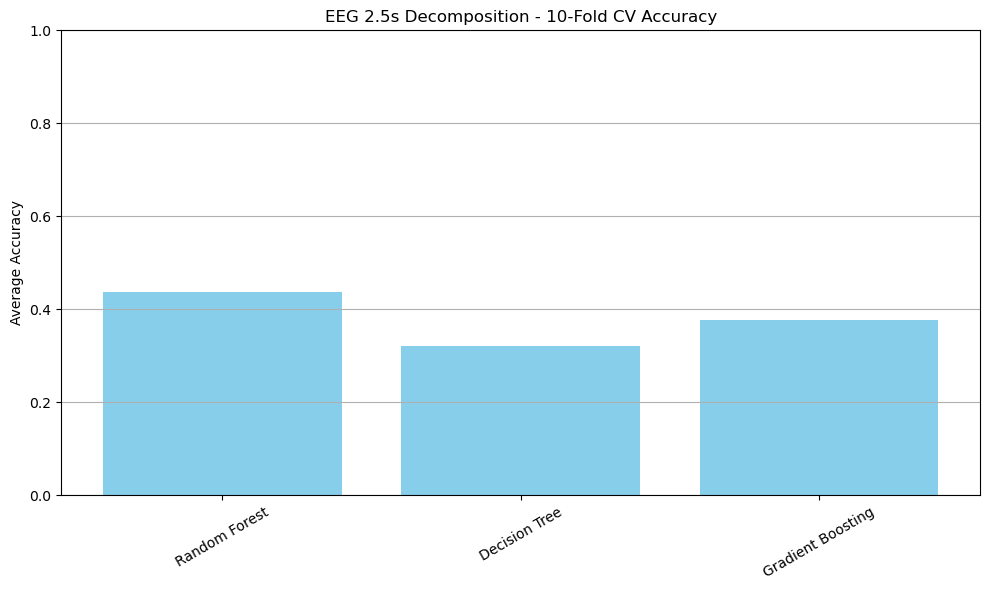

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/channel selection/processed_data/labels.csv', header=None, skiprows=1).squeeze()

# Feature scaling - improves SVM, KNN, etc.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models (with better tuned hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    # Optional: Add SVM or Logistic Regression with tuning
    
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()